#CLASSIFICAZIONE
Dopo aver analizzato a fondo il nostro modello, vogliamo fare un confronto tra diversi classificatori e comprendere quale modello si adatta meglio ai nostri dati e riesce a effettuare previsioni più accurate

Proviamo i diversi modelli prima sulle prime 30 variabili più significative e poi usando le prime 20 e 30 PCA così da capire quale metodo sia migliore e classifichi meglio i dati

Passiamo al corpo del nostro progetto, ovvero la classificazione del modello di modo da poter fare previsioni sul comportamento di dati non osservati e addestrare un modello che si adatti bene ai nostri dati.

In base al problema, spesso gli approcci dei classici algoritmi di machine learing lavorano bene sui dati tabulari e abbiamo una vasta gamma di soluzioni tra cui scegliere.

Spesso i modelli lineari si adattano bene ai nostri dati, tuttavia nel nostro caso anche attraverso le rappresentazioni grafiche abbiamo appurato che soluzioni non lineari classificano meglio i nostri dati, quindi decidiamo di affidarci a architetture di deep learning come il gradient boosting.



Useremo una metodologia di base per implementare i diversi approcci di modo da renderli facilmente comparabili:
- definiamo una pipeline che incorpori sia la trasformazione dei dati che la modellazione
- settiamo una misura di errore per misurare l'accuratezza del modello e misurarla tramite cross validation
- avarage e standard deviation (cruciale per capire se il modello ha performance costante in diversi campioni) dell'errore calcolato con la cross validation

In [ ]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from pytorch_tabnet.tab_model import TabNetClassifier

from src.data_loading import load_class_data
from src.eda_utils import remove_correlated_features, seleziona_variabili_pca
from src.preprocessing import build_preprocessing_pipeline, preprocess_arrays
from src.evaluation import evaluate_model, plot_confusion_matrix

##uploading dei dati

In [ ]:
TRAIN_FEATURES_PATH = "../data/train_features_bone_marrow.h5"
TEST_FEATURES_PATH = "../data/test_features_bone_marrow.h5"

X_train, y_train = load_class_data(TRAIN_FEATURES_PATH)
X_test, y_test = load_class_data(TEST_FEATURES_PATH)

In [ ]:
df_train = pd.DataFrame(X_train)
df_test = pd.DataFrame(X_test)

df_train[64] = y_train
df_test[64] = y_test

df_train[64] = df_train[64].astype('category').cat.codes #codifichiamo la variabile target come categoriale
df_test[64] = df_test[64].astype('category').cat.codes

In [ ]:
X_train_filtered, to_drop = remove_correlated_features(df_train.iloc[:, :-1], threshold=0.5)
df_filtered = df_train.drop(columns=to_drop)

Variabili eliminate perché correlate > ±0.5:
[14, 17, 22, 35, 36, 40, 61]
Nuova forma del dataset: (44800, 58)


In [ ]:
df_ridotto = seleziona_variabili_pca(df_filtered)

In [ ]:
column_names = df_ridotto.columns.tolist()
column_names

[56,
 15,
 21,
 30,
 31,
 53,
 32,
 48,
 45,
 50,
 51,
 55,
 11,
 26,
 1,
 19,
 0,
 20,
 7,
 39,
 62,
 41,
 27,
 13,
 4,
 47,
 25,
 59,
 46,
 33,
 64]

In [ ]:
df_train = df_train.loc[:, df_train.columns.isin(column_names)]
df_train
df_train.columns = list(range(31))

In [ ]:
df_test = df_test.loc[:, df_test.columns.isin(column_names)]
df_test
df_test.columns = list(range(31))

##Decision trees e modelli aggregati

Gli alberi decisionali sono alla base dei modelli aggregati come il random forest e il gradiend boosting.

L'idea di base dietro gli alberi decisionali è che è possibile suddividere il training set in sottoinsiemi in cui la previsione risulta più favorevole, in quanto è presente una classe di output predominante.

Si inizia dalla radice dell'albero, che corrisponde all'intero dataset e da un insieme di condizioni per lo split (solitamente booleane).

Ogni ramo porta a un altro nodo, dove si applicherà una nuova condizione per lo split.

Come criterio di suddivisione in un problema di classificazione, l'algoritmo degli alberi decisionali cerca la migliore combinazione tra variabile e valore della variabile che suddivida i dati in sottoinsiemi con un target omogeneo.

Nel processo di addestramento, vi è una selezione automatica delle migliori variabili, e la maggior parte dei calcoli per un albero decisionale riguarda la determinazione delle suddivisioni ottimali delle variabili. Tuttavia, una volta che l'albero è stato costruito, la previsione della class label o del valore target per nuovi dati è relativamente rapida e semplice, e consiste nel percorrere l’albero a partire dalla radice fino a una foglia, in base ai valori di un insieme limitato di variabili.

Gli alberi decisionali sono semplici da calcolare e relativamente facili da visualizzare. Non richiedono operazioni di scaling, modellazione di non linearità o trasformazioni delle variabili o del target, poiché sono in grado di approssimare qualsiasi relazione non lineare tra variabile target e predittori, grazie alla capacità di considerare separatamente singole parti della loro distribuzione.

Se un singolo algoritmo è in grado di ottenere determinati risultati, l'utilizzo delle intuizioni di più modelli, o la loro combinazione in sequenza (in modo che uno possa apprendere dai risultati e dagli errori dell'altro), dovrebbe portare a risultati ancora migliori.

Esistono due strategie principali di aggregazione (ensemble):
- Averaging: le predizioni si ottengono facendo la media delle predizioni di più modelli. Le differenze nel modo in cui i modelli vengono costruiti, ad esempio mediante pasting, bagging, random subspaces e random patches, come vedremo in questa sezione, portano a risultati differenti. Il miglior esempio di modelli ensemble di questo tipo è il Random Forests, che si basa su un approccio simile ai random patches.
- Boosting: Le predizioni vengono costruite come una media ponderata di modelli concatenati, cioè modelli costruiti sequenzialmente sui risultati dei modelli precedenti. Il miglior esempio di algoritmo di boosting sono le gradient boosting machines, come XGBoost e LightGBM.

In [ ]:
X_train = df_train.iloc[:, :-1]
y_train = df_train.iloc[:, -1]
X_test = df_test.iloc[:, :-1]
y_test = df_test.iloc[:, -1]
numeric_columns = X_train.columns.tolist()

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

## Random Forest
Effettua il bootstrap dei campioni prima che ciascun modello venga addestrato e sottocampiona le variabili durante la modellazione.

Il bootstrapping consiste nel campionare con reinserimento più volte da un campione di dati per approssimare la distribuzione della popolazione di una statistica. Il bootstrapping è una tecnica statistica ampiamente utilizzata che ci consente di stimare la variabilità e l’incertezza delle statistiche rispetto alla popolazione sottostante da cui è stato estratto il nostro campione. Utilizzando le informazioni disponibili nel campione attraverso molteplici ricampionamenti che imitano il comportamento della popolazione originale, il bootstrapping emula il comportamento della popolazione senza richiedere una conoscenza esplicita della sua distribuzione statistica.

Poiché l'algoritmo di base utilizzato in un ensemble di random forests è un albero decisionale costruito mediante suddivisioni binarie, il campionamento delle variabili avviene a ogni split dell'albero, quando un insieme di variabili viene selezionato come potenziali candidate per la suddivisione stessa.

Consentire a ciascun albero decisionale nell’ensemble di crescere fino alle sue estremità può portare a un overfitting dei dati e a un’elevata varianza nelle stime; l’utilizzo del bootstrapping e del campionamento delle variabili può contribuire a mitigare questi problemi. Il bootstrapping garantisce che i modelli vengano addestrati su campioni di dati leggermente differenti ma provenienti dalla stessa distribuzione, mentre il campionamento delle variabili a ogni suddivisione assicura strutture arboree diversificate. Questa combinazione permette di generare un insieme di modelli piuttosto distinti tra loro. Modelli differenti producono previsioni molto diverse (possiamo quindi dire che le loro previsioni sono poco correlate), e questo rappresenta un grande vantaggio per la tecnica di media, poiché, aggregando le predizioni in un singolo vettore di previsione, si ottengono risultati più affidabili e accurati.

Il segreto per ottenere buoni risultati con il random forest è di scegliere bene gli iperparametri. Nonostante l'algoritmo lavori bene con i parametri di default, il fine-tuning degli iperparametri ci farà avere risultati migliori.

Innanzitutto, lo scopo dell'algoritmo è ridurre la varianza delle stime, e ciò viene ottenuto impostando un numero sufficientemente alto di alberi (n_estimators).
Il principio alla base è che, disponendo di molti alberi, si ottiene una distribuzione di risultati; e se questi risultati sono estratti in modo casuale, si verifica un effetto simile alla regressione verso la media (ossia la migliore previsione), grazie alla legge dei grandi numeri.

Tuttavia, è necessario effettuare dei test per regolare finemente il numero ottimale di alberi da costruire, poiché esiste sempre un punto ideale: superata una certa soglia, non si ottengono più miglioramenti e, talvolta, si possono persino osservare cali di performance. Inoltre, impostare un numero eccessivamente alto di alberi comporta costi computazionali maggiori, richiedendo più tempo sia in fase di addestramento che di previsione.

In [ ]:
column_transform = build_preprocessing_pipeline(numeric_columns)

rf_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=3,
    random_state=0,
    max_depth=6,
)

rf_pipeline = Pipeline([
    ('processing', column_transform),
    ('modeling', rf_model)
])

In [ ]:
rf_pipeline.fit(X_train, y_train, modeling__sample_weight=sample_weights)
predizioni = rf_pipeline.predict(X_test)

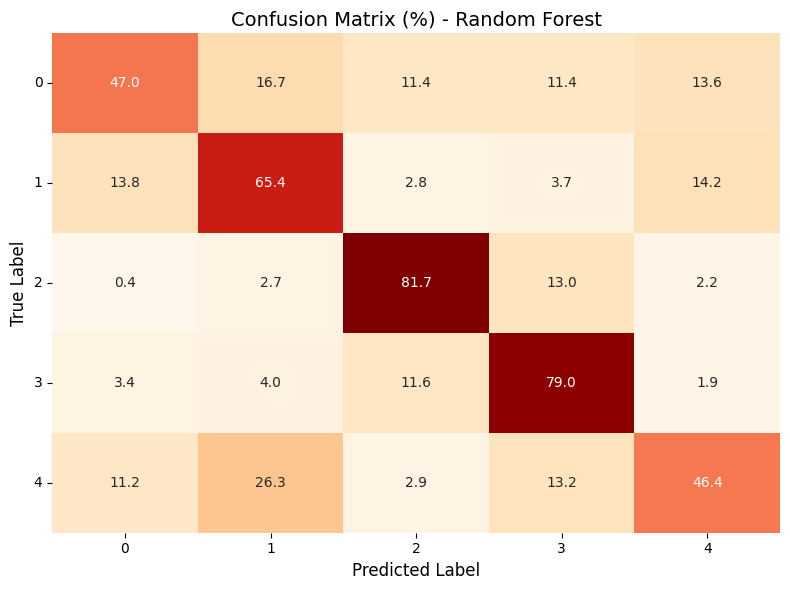

In [ ]:
plot_confusion_matrix(y_test, predizioni, "Random Forest", cmap="OrRd", normalize=True)

In [ ]:
rf_metrics = evaluate_model(y_test, predizioni, model_name="Random Forest")

              precision    recall  f1-score   support

           0       0.08      0.47      0.14       132
           1       0.57      0.65      0.61      1765
           2       0.87      0.82      0.84      8219
           3       0.83      0.79      0.81      7873
           4       0.48      0.46      0.47      1212

    accuracy                           0.77     19201
   macro avg       0.57      0.64      0.57     19201
weighted avg       0.79      0.77      0.78     19201



## Gradient boosting

In questo paragrafo ci focalizziamo sul gradiend boosting e le sue implementazioni principali ovvero XGBoost (eXtreme Gradient Boosting) e Light GBM (Light Gradient Boosted Machines) che sono considerate soluzioni all'avanguardia per i dati tabellari.

Nel gradient boosting, si parte da un valore costante e si aggiungono sequenzialmente modelli ad albero a un ensemble, in cui ogni nuovo albero cerca di correggere gli errori commessi dai modelli precedenti. Questo processo è simile all’ottimizzazione tramite discesa del gradiente, in cui si riduce gradualmente la funzione di perdita. Il gradient boosting rappresenta un miglioramento rispetto all’approccio tradizionale di boosting, rendendo il modello più efficace nel correggere gli errori.

Nel gradient boosting si fa affidamento su una doppia ottimizzazione: prima quella dei singoli alberi, che cercano di ridurre l’errore basandosi sulla loro funzione di ottimizzazione, e poi quella generale, che coinvolge il calcolo dell’errore complessivo dell’ensemble potenziato, in una forma che imita la discesa del gradiente, correggendo gradualmente le previsioni del modello.
Poiché l’ottimizzazione avviene anche a un secondo livello, basato sull’errore dell’intera procedura di ensemble, il gradient boosting risulta più versatile rispetto agli ensemble di alberi visti in precedenza, in quanto consente di utilizzare funzioni di perdita arbitrarie per calcolare quanto la somma delle predizioni dei modelli si discosta dai risultati attesi.

Tutte le implementazioni di Gradient Boosting Decision Trees (GBDT) offrono una varietà di iperparametri che devono essere settati per avere buoni risultati. Capire come settarli è la sfida principale.

###XGBOOST

In [ ]:
column_transform = build_preprocessing_pipeline(numeric_columns)

xgb_model = XGBClassifier(
    objective='multi:softprob',
    num_class=5,
    eval_metric='mlogloss',
    min_samples_leaf=3,
    use_label_encoder=False,
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=0,
)

xgb_pipeline = Pipeline([
    ('processing', column_transform),
    ('modeling', xgb_model)
])

In [ ]:
start_train = time.time()
xgb_pipeline.fit(X_train, y_train, modeling__sample_weight=sample_weights)
train_time = time.time() - start_train

start_pred = time.time()
y_pred = xgb_pipeline.predict(X_test)
pred_time = time.time() - start_pred

print(f"Tempo di training (XGBoost): {train_time:.2f} secondi")
print(f"Tempo di predizione (XGBoost): {pred_time:.2f} secondi")

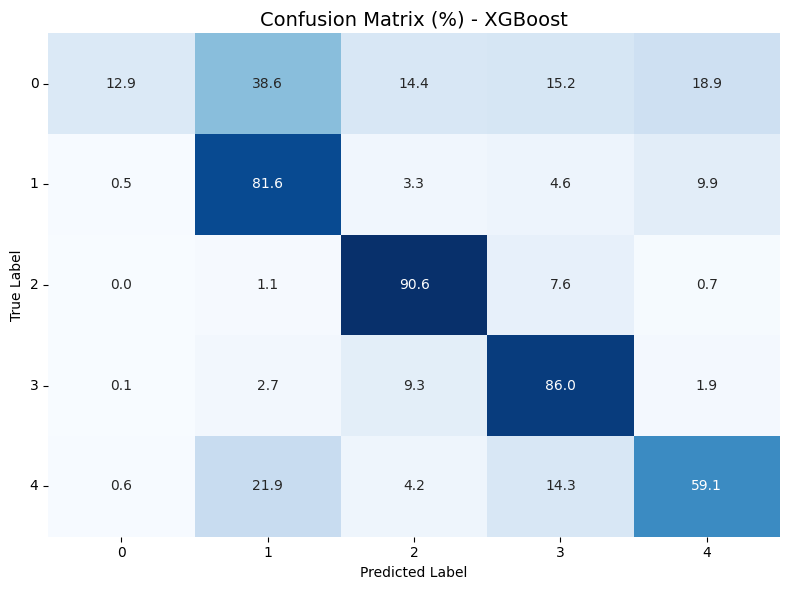

In [ ]:
plot_confusion_matrix(y_test, y_pred, "XGBoost", cmap="Blues", normalize=True)

In [ ]:
xgb_metrics = evaluate_model(y_test, y_pred, model_name="XGBoost")

Balanced Accuracy: 0.66
F1 Macro: 0.667
Accuracy: 0.8537
Recall Macro: 0.660

Classification Report:
               precision    recall  f1-score   support

           0       0.42      0.13      0.20       132
           1       0.70      0.82      0.75      1765
           2       0.90      0.91      0.90      8219
           3       0.88      0.86      0.87      7873
           4       0.64      0.59      0.61      1212

    accuracy                           0.85     19201
   macro avg       0.71      0.66      0.67     19201
weighted avg       0.85      0.85      0.85     19201



###LightGBM

In [ ]:
column_transform = build_preprocessing_pipeline(numeric_columns)

lgbm_model = LGBMClassifier(
    objective='multiclass',
    num_class=5,
    eval_metric='multi_logloss',
    min_samples_leaf=3,
    use_label_encoder=False,
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=0,
)

lgbm_pipeline = Pipeline([
    ('processing', column_transform),
    ('modeling', lgbm_model)
])

In [ ]:
start_train = time.time()
lgbm_pipeline.fit(X_train, y_train, modeling__sample_weight=sample_weights)
train_time = time.time() - start_train

start_pred = time.time()
y_pred = lgbm_pipeline.predict(X_test)
pred_time = time.time() - start_pred

print(f"Tempo di training (LightGBM): {train_time:.2f} secondi")
print(f"Tempo di predizione (LightGBM): {pred_time:.2f} secondi")

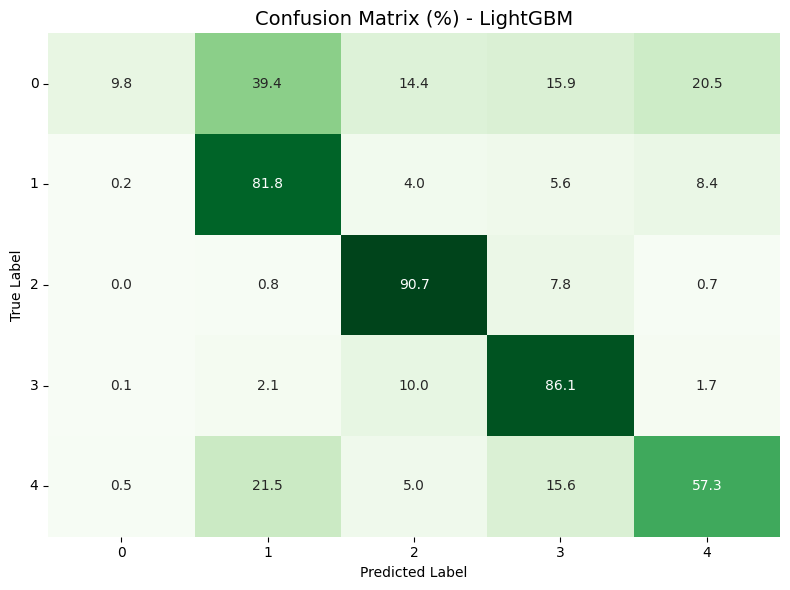

In [ ]:
plot_confusion_matrix(y_test, y_pred, "LightGBM", cmap="Greens", normalize=True)

In [ ]:
lgbm_metrics = evaluate_model(y_test, y_pred, model_name="LightGBM")

Balanced Accuracy: 0.652
F1 Macro: 0.662
Accuracy: 0.8532
Recall Macro: 0.652

Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.10      0.16       132
           1       0.72      0.82      0.77      1765
           2       0.89      0.91      0.90      8219
           3       0.88      0.86      0.87      7873
           4       0.66      0.57      0.61      1212

    accuracy                           0.85     19201
   macro avg       0.73      0.65      0.66     19201
weighted avg       0.85      0.85      0.85     19201



##TabNet

In [ ]:
X_train_arr, X_test_arr = preprocess_arrays(X_train.values, X_test.values)
y_train_arr = y_train.values
y_test_arr = y_test.values

tabnet_model = TabNetClassifier(
    n_d=32,
    n_a=32,
    n_steps=5,
    gamma=1.5,
    n_independent=2,
    n_shared=2,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size": 50, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='entmax',
    seed=0,
    verbose=10,
    device_name='cuda' if torch.cuda.is_available() else 'cpu',
)

In [ ]:
tabnet_model.fit(
    X_train=X_train_arr,
    y_train=y_train_arr,
    eval_set=[(X_test_arr, y_test_arr)],
    eval_name=['val'],
    eval_metric=['balanced_accuracy'],
    max_epochs=200,
    patience=20,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False,
    weights=sample_weights
)

In [ ]:
preds = tabnet_model.predict(X_test_arr)

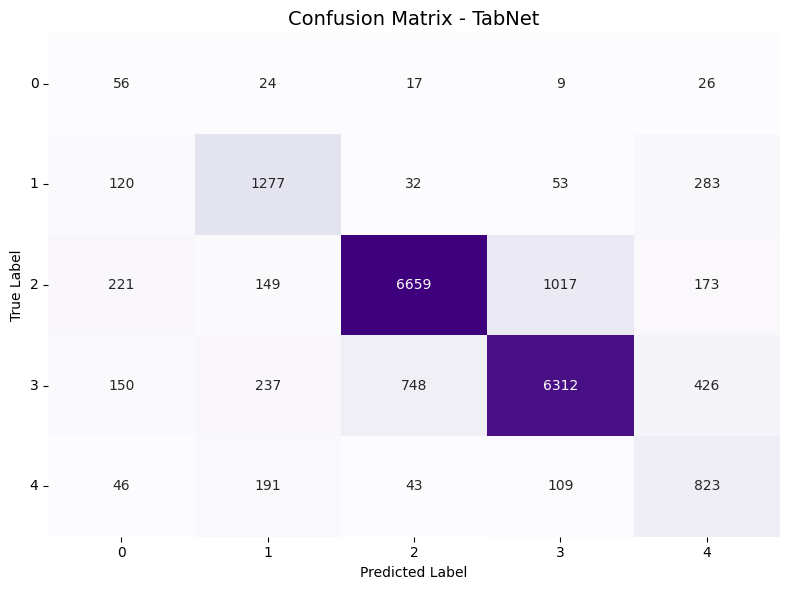

In [ ]:
plot_confusion_matrix(y_test_arr, preds, "TabNet", cmap="Purples", normalize=False)

In [ ]:
plot_confusion_matrix(y_test_arr, preds, "TabNet", cmap="Purples", normalize=True)

In [ ]:
tabnet_metrics = evaluate_model(y_test_arr, preds, model_name="TabNet")


Classification Report:
              precision    recall  f1-score   support

           0       0.09      0.42      0.15       132
           1       0.68      0.72      0.70      1765
           2       0.89      0.81      0.85      8219
           3       0.84      0.80      0.82      7873
           4       0.48      0.68      0.56      1212

    accuracy                           0.79     19201
   macro avg       0.60      0.69      0.62     19201
weighted avg       0.82      0.79      0.80     19201

Balanced Accuracy: 0.6877442773646635
F1 Macro: 0.6166670703749977
Accuracy: 0.7878235508567262


NameError: name 'recall_score' is not defined